# Análisis exploratorio de datos

El conjunto de datos utilizado en este proyecto se denomina [Poker Hand](https://archive.ics.uci.edu/dataset/158/poker+hand) y fue conseguido en el sitio web UCI Machine Learning Repository.

![](imagenes/mazo.avif)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

train_path = "datosDePoquer/poker-hand-training-true.data"
test_path = "datosDePoquer/poker-hand-testing.data"

column_names = ["S1", "C1", "S2", "C2", "S3", "C3", "S4", "C4", "S5", "C5", "Clase"]

df_train = pd.read_csv(train_path, names=column_names)
df_test = pd.read_csv(test_path, names=column_names)

df_train.tail(12)

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,Clase
24998,1,8,4,1,4,12,1,13,1,10,0
24999,4,12,3,11,4,4,3,12,2,12,3
25000,2,8,2,12,4,3,4,2,4,4,0
25001,2,12,3,5,3,8,4,1,4,2,0
25002,4,10,2,13,4,5,4,7,1,5,1
25003,1,12,2,9,2,12,4,8,1,13,1
25004,3,5,3,7,4,11,3,11,3,2,1
25005,3,9,2,6,4,11,4,12,2,4,0
25006,4,1,4,10,3,13,3,4,1,10,1
25007,2,1,2,10,4,4,4,1,4,13,1


El conjunto de datos cuenta con 10 variables predictoras y una variable objetivo. Se reciben 5 cartas (lo que se conoce como una mano) identificadas con una figura (S) y un valor (C), y se clasifica en algunas de las diez posibles manos de póquer.

In [87]:
print("Dimensiones del conjunto de entrenamiento:", df_train.shape)
print("Dimensiones del conjunto de prueba:", df_test.shape)

Dimensiones del conjunto de entrenamiento: (25010, 11)
Dimensiones del conjunto de prueba: (1000000, 11)


In [88]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25010 entries, 0 to 25009
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   S1      25010 non-null  int64
 1   C1      25010 non-null  int64
 2   S2      25010 non-null  int64
 3   C2      25010 non-null  int64
 4   S3      25010 non-null  int64
 5   C3      25010 non-null  int64
 6   S4      25010 non-null  int64
 7   C4      25010 non-null  int64
 8   S5      25010 non-null  int64
 9   C5      25010 non-null  int64
 10  Clase   25010 non-null  int64
dtypes: int64(11)
memory usage: 2.1 MB


Los siguientes gráficos ilustran cómo se distribuyen los distintos tipos de manos de póquer (las clases) en los conjuntos de entrenamiento y prueba.

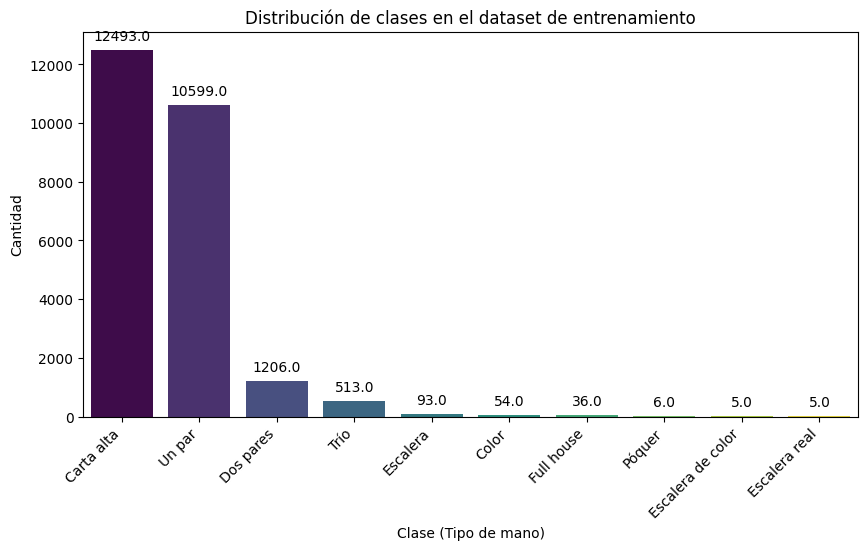

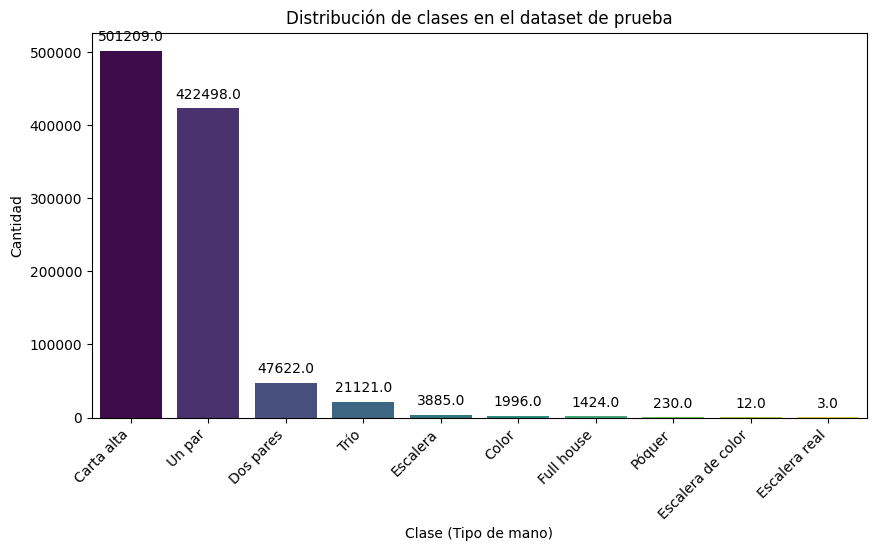

In [89]:
clase_nombres = {
    0: "Carta alta",
    1: "Un par",
    2: "Dos pares",
    3: "Trío",
    4: "Escalera",
    5: "Color",
    6: "Full house",
    7: "Póquer",
    8: "Escalera de color",
    9: "Escalera real"
}

plt.figure(figsize=(10,5))
ax = sns.countplot(x=df_train["Clase"], hue=df_train["Clase"], palette="viridis", legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0,5), 
                textcoords='offset points')
    
ax.set_xticks(list(clase_nombres.keys()))
ax.set_xticklabels(list(clase_nombres.values()), rotation=45, ha="right")
    
plt.title("Distribución de clases en el dataset de entrenamiento")
plt.xlabel("Clase (Tipo de mano)")
plt.ylabel("Cantidad")
plt.show()

plt.figure(figsize=(10,5))
ax2 = sns.countplot(x=df_test["Clase"], hue=df_test["Clase"], palette="viridis", legend=False)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0,5), 
                textcoords='offset points')
    
ax2.set_xticks(list(clase_nombres.keys()))
ax2.set_xticklabels(list(clase_nombres.values()), rotation=45, ha="right")
    
plt.title("Distribución de clases en el dataset de prueba")
plt.xlabel("Clase (Tipo de mano)")
plt.ylabel("Cantidad")
plt.show()

Se evidencia la similitud de las proporciones entre conjuntos. Además de un claro desbalance de clases, que es fiel relflejo de la realidad, porque, por ejemplo, de las más de 2 millones y medio de manos posibles, algo más de la mitad pertenecen a la clase "Carta alta" (identificada con 0 en el dataset).

Ahora se verifican los valores únicos de cada atributo, es decir, que las figuras de las cartas están representadas por números del 1 al 4, y sus valores por números del 1 al 13.

In [90]:
for i in range(1, 6):
    print(f"Valores únicos de S{i} (Palo de la carta {i}): {df_train[f'S{i}'].unique()}")
    print(f"Valores únicos de C{i} (Rango de la carta {i}): {df_train[f'C{i}'].unique()}")

Valores únicos de S1 (Palo de la carta 1): [1 2 3 4]
Valores únicos de C1 (Rango de la carta 1): [10 11 12  1  2  9  5  6 13  8  3  4  7]
Valores únicos de S2 (Palo de la carta 2): [1 2 3 4]
Valores únicos de C2 (Rango de la carta 2): [11 13  4 12  2  6  1  7  8 10  5  9  3]
Valores únicos de S3 (Palo de la carta 3): [1 2 3 4]
Valores únicos de C3 (Rango de la carta 3): [13 10  1 12  5  3  9  2  4  7  6 11  8]
Valores únicos de S4 (Palo de la carta 4): [1 2 3 4]
Valores únicos de C4 (Rango de la carta 4): [12 10 13 11  3  4  7  5  1  2  6  9  8]
Valores únicos de S5 (Palo de la carta 5): [1 2 3 4]
Valores únicos de C5 (Rango de la carta 5): [ 1 12 10  6 13  5  8  3  9 11  2  7  4]


En efecto, no hay valores incorrectos como números negativos ni números que no se correspondan con los atributos.

También convinene revisar la inexistencia de correlación entre las variables predictoras.

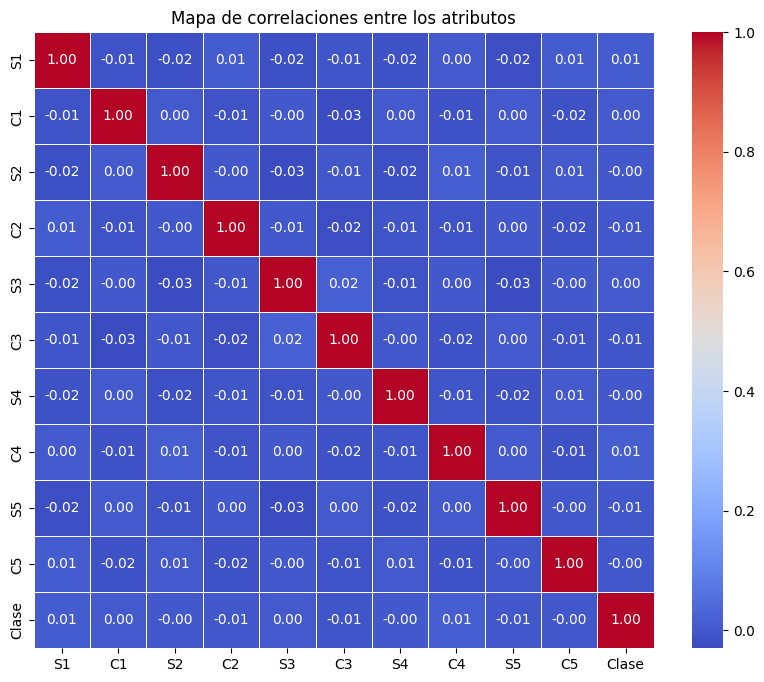

In [91]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de correlaciones entre los atributos")
plt.show()

Con el mapa anterior, se comprueba que las figuras y los valores de las cartas no guardan relación entre sí.

Otro aspecto a considerar, es la distribución de cada atributo, esto es, cómo están representados los valores y los palos de las cartas en el dataset.

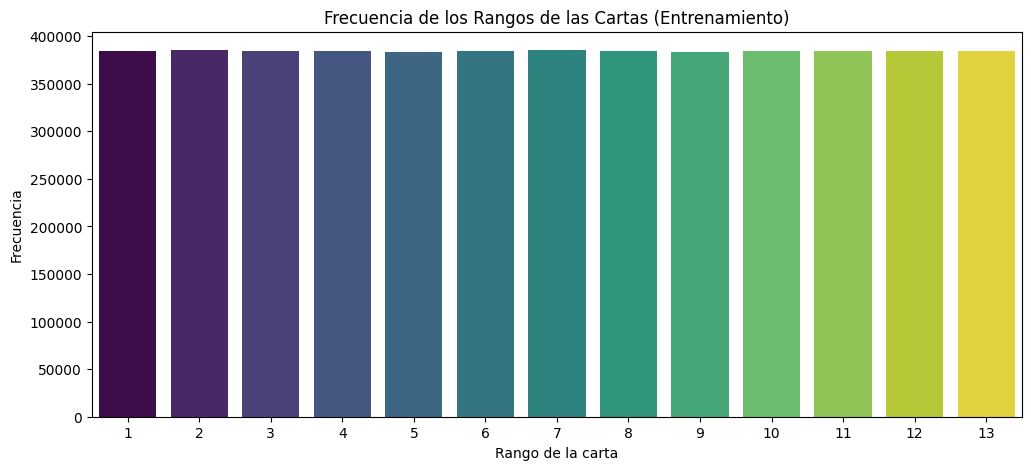

<Figure size 800x500 with 0 Axes>

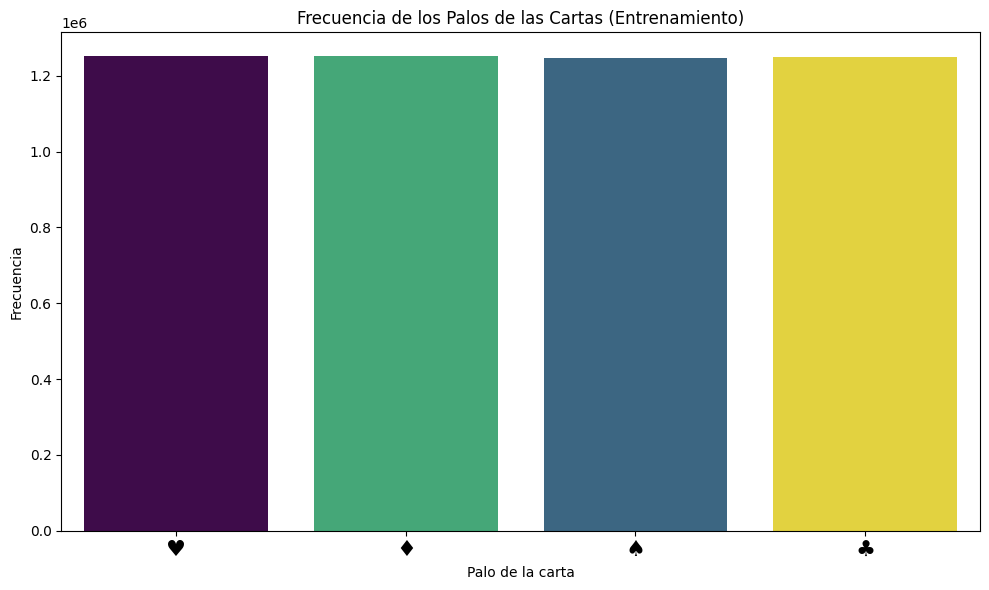

In [ ]:
plt.figure(figsize=(12, 5))
concatRango = pd.concat([df_train[f"C{i}"] for i in range(1, 6)])
sns.countplot(x=concatRango, hue=concatRango, palette="viridis", legend=False)
plt.title("Frecuencia de los Rangos de las Cartas (Entrenamiento)")
plt.xlabel("Rango de la carta")
plt.ylabel("Frecuencia")
plt.show()
plt.figure(figsize=(8, 5))

concatPalo = pd.concat([df_train[f"S{i}"] for i in range(1, 6)])
suit_mapping = {1: '♥', 2: '♠', 3: '♦', 4: '♣'}
concatPalo_named = concatPalo.map(suit_mapping)
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=concatPalo_named, hue=concatPalo, palette="viridis", legend=False)
plt.xticks(fontsize=16)
plt.title("Frecuencia de los Palos de las Cartas (Entrenamiento)")
plt.xlabel("Palo de la carta")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


Como se esperaba, tanto los valores como las figuras de las cartas tienen distribuciones muy parecidas, o sea, no hay un palo ni un rango que esté significativamente más representado que otro (como si hubieran muchos más corazones que tréboles, o muchos menos ases que cincos).

Por último, se contemplará específicamente cómo se distribuyen los palos en cada tipo de mano. Para eso se examinará la figura que más veces se repite en la mano, y también se realizará una prueba de hipótesis, con el fin de determinar si existe alguna asociación o influencia entre el tipo de mano de póquer y el palo dominante de dicha mano.

<Figure size 1500x800 with 0 Axes>

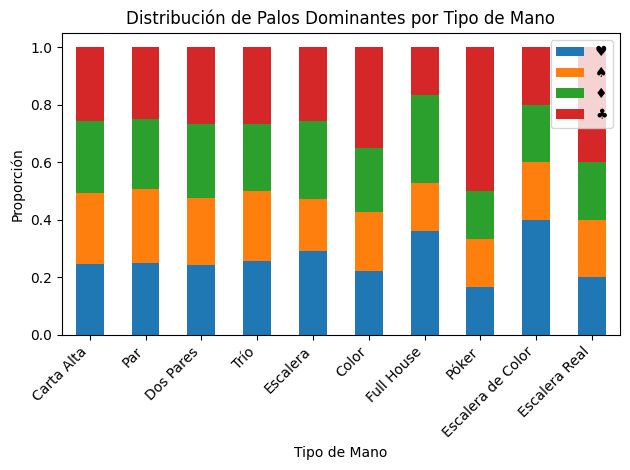

In [93]:
def analyze_suit_distribution(df):
    # Función para encontrar el palo dominante en una mano
    def get_dominant_suit(row):
        suits = [row[f'S{i}'] for i in range(1, 6)]
        suit_counts = pd.Series(suits).value_counts()
        return suit_counts.index[0] if len(suit_counts) > 0 else None

    # Mapeo de números a palos para mejor visualización
    hand_mapping = {
        0: 'Carta Alta',
        1: 'Par',
        2: 'Dos Pares',
        3: 'Trío',
        4: 'Escalera',
        5: 'Color',
        6: 'Full House',
        7: 'Póker',
        8: 'Escalera de Color',
        9: 'Escalera Real'
    }

    # Calcular palo dominante para cada mano
    df['palo_dominante'] = df.apply(get_dominant_suit, axis=1)
    
    # Crear tabla de contingencia
    contingency_table = pd.crosstab(df['Clase'], df['palo_dominante'])
    
    # Renombrar filas y columnas para mejor visualización
    contingency_table.index = [hand_mapping[i] for i in contingency_table.index]
    contingency_table.columns = [suit_mapping.get(col, col) for col in contingency_table.columns]
    
    # Realizar prueba chi-cuadrado
    chi2, p_value = stats.chi2_contingency(contingency_table)[:2]
    
    # Visualización
    plt.figure(figsize=(15, 8))
    
    # Gráfico de barras apiladas normalizado
    contingency_table_norm = contingency_table.div(contingency_table.sum(axis=1), axis=0)
    ax = contingency_table_norm.plot(kind='bar', stacked=True)
    
    plt.title('Distribución de Palos Dominantes por Tipo de Mano')
    plt.xlabel('Tipo de Mano')
    plt.ylabel('Proporción')
    
    # Renombrar etiquetas
    ax.set_xticklabels(contingency_table.index, rotation=45, ha='right')
    
    plt.tight_layout()
    
    return {
        'chi2_statistic': chi2,
        'p_value': p_value,
        'contingency_table': contingency_table,
        'normalized_distribution': contingency_table_norm
    }

results = analyze_suit_distribution(df_train)

Con el gráfico se aprecia que las primeras seis clases (las que están más representadas) presentan una relativa paridad entre los palos, a modo de ejemplo, de todas las muestras que pertenecen a la clase 'Trío', aproximadamente un cuarto tiene como palo mayoritario al trébol, otro cuarto al diamante, y otro cuarto al corazón.

Las siguientes tablas contienen la misma información del gráfico, pero expuesta con números. Lo que permite comprender esa falta de homogeneidad de las figuras en las cuatro clases con menos muestras en el dataset.

In [94]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'center')

# Para las tablas específicas
print("\n=== TABLA DE FRECUENCIAS ABSOLUTAS ===")
print(results['contingency_table'].to_string(index=True, justify='center'))

print("\n=== TABLA DE PROPORCIONES ===")
print(results['normalized_distribution'].round(4).to_string(index=True, justify='center'))

print(f"\nEstadístico Chi-cuadrado: {results['chi2_statistic']:.4f}")
print(f"p-valor: {results['p_value']:.10f}")


=== TABLA DE FRECUENCIAS ABSOLUTAS ===
                     ♥     ♠     ♦     ♣ 
Carta Alta         3079  3105  3122  3187
Par                2670  2691  2595  2643
Dos Pares           292   281   311   322
Trío                132   125   120   136
Escalera             27    17    25    24
Color                12    11    12    19
Full House           13     6    11     6
Póker                 1     1     1     3
Escalera de Color     2     1     1     1
Escalera Real         1     1     1     2

=== TABLA DE PROPORCIONES ===
                      ♥       ♠       ♦       ♣  
Carta Alta         0.2465  0.2485  0.2499  0.2551
Par                0.2519  0.2539  0.2448  0.2494
Dos Pares          0.2421  0.2330  0.2579  0.2670
Trío               0.2573  0.2437  0.2339  0.2651
Escalera           0.2903  0.1828  0.2688  0.2581
Color              0.2222  0.2037  0.2222  0.3519
Full House         0.3611  0.1667  0.3056  0.1667
Póker              0.1667  0.1667  0.1667  0.5000
Escalera de Color

Se concluye de las tablas que, esa diferencia vista en el gráfico anterior entre la distribución de los distintos palos sobre las últimas clases, es consecuencia de las pocas muestras que existen en el conjunto de datos, y que deberá ser tratada antes de implementar cualquier modelo.

En adición, el p-valor en este análisis chi-cuadrado es muy grande, lo que sugiere que no hay evidencia suficiente para afirmar que existe una asociación entre los tipos de manos y los palos dominantes, lo cual es natural por la aleatoriedad involucrada en la selección de cartas de un mazo bien barajado.